# Binary Text Classification with BERT and PyTorch Lightning on the IMBD movie reviews dataset

Steps to solve the homework:
1. Load and preprocess the data.
2. Understand data distribution and possible class imbalance.
3. Create a PyTorch Dataset according to the BERT input format.
4. Define a PyTorch Lightning Module that uses a pre-trained BERT and a classification head for binary classification.
5. Train and evaluate the model.
6. Analyze results.

We will follow the same stesps as the example notebook with appropriate modifications for the binary classification task.

## Library Imports

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

import pandas as pd
import numpy as np

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import random_split, Dataset, DataLoader
from torch.optim import AdamW

from transformers import BertTokenizerFast as BertTokenizer, BertModel, get_linear_schedule_with_warmup

import pytorch_lightning as pl
import torchmetrics
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import TQDMProgressBar, RichProgressBar

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, multilabel_confusion_matrix

import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from torchmetrics import AUROC, Accuracy, F1Score, Precision, Recall, AveragePrecision, HammingDistance

from settings import DATA_DIR, LOGS_DIR
from utils.data_downloader import download_and_extract

/home/docampor/usfq-mmia/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Parametros para gráficos

%matplotlib inline
%config InlineBackend.figure_format='retina'

RANDOM_SEED = 42

sns.set(style='whitegrid', palette='muted', font_scale=1.2)
HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))
rcParams['figure.figsize'] = 8,6

pl.seed_everything(RANDOM_SEED)

Seed set to 42


42

## Dataset

The dataset consists of 50,000 movie reviews from IMDB. It is accesible on Kaggle: was originally released for the [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/api/v1/datasets/download/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews) on Kaggle.

In [5]:
url = "https://www.kaggle.com/api/v1/datasets/download/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"
name = "imdb-dataset-of-50k-movie-reviews"
filetype = "zip"

download_and_extract(
    url=url,
    name=name,
    filetype=filetype,
)

El dataset imdb-dataset-of-50k-movie-reviews ya existe. Omitiendo descarga.


The full dataset is approximately 66.21 MB, small enough to load entirely into RAM as a Pandas DataFrame. Loading into memory avoids repeated disk I/O during tokenization and sampling.

In [7]:
csv_path = f"{DATA_DIR}/{name}/IMDB Dataset.csv"
df = pd.read_csv(csv_path)
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Each row in the DataFrame contains the raw review text in the `review` column,  and a classification label in the `sentiment` columns as either "positive" or "negative".

**Data exploration**: We print the raw counts of toxic and clean comments to quantify the class imbalance before any sampling. Knowing that clean comments far outnumber toxic ones directly motivates the undersampling step that follows.

In [ ]:
LABEL_COLUMNS = df.columns.tolist()[2:]
df_toxic = df[df[LABEL_COLUMNS].sum(axis=1) > 0]
df_clean = df[df[LABEL_COLUMNS].sum(axis=1) == 0]
print("Number of offensive samples: ", len(df_toxic))
print("Number of non-offensive (clean) samples: ", len(df_clean))

The dataset is heavily imbalanced: clean comments far outnumber toxic ones. Training on the raw distribution would cause the model to learn a trivial strategy of predicting "clean" for every input, achieving high accuracy but failing to detect any toxicity.

We address this in two complementary ways:

1. **Undersampling**: We randomly draw a fixed number of clean comments (`16,225`) to bring the class ratio closer to balance.
2. **Weighted loss**: Later, we compute per-class positive weights for `BCEWithLogitsLoss` so the loss penalizes false negatives on minority classes more heavily.

In [ ]:
filter_df = pd.concat([
  df_toxic,
  df_clean.sample(16225)
])

filter_df.shape

**Data exploration**: Printing the size of each split verifies that the 70/15/15 proportions were applied correctly and that no samples were silently dropped during shuffling or indexing. Always confirm split sizes before training — an off-by-one error here can invalidate your entire experiment.

In [ ]:
train_frac, val_frac, test_frac = 0.7, 0.15, 0.15

# Shuffle the DataFrame
filter_df = filter_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Calcular los indices para separar los subsets
train_end = int(train_frac * len(filter_df))
val_end = train_end + int(val_frac * len(filter_df))

# Split the DataFrame
train_df = filter_df[:train_end]
val_df = filter_df[train_end:val_end]
test_df = filter_df[val_end:]

print("Train DataFrame:\n", len(train_df))
print("Validation DataFrame:\n", len(val_df))
print("Test DataFrame:\n", len(test_df))

In [ ]:
train_df.head()

In [ ]:
from matplotlib.ticker import ScalarFormatter

# Count per offensive label
label_counts = filter_df[LABEL_COLUMNS].sum().sort_values(ascending=False)

# Add non-offensive count (rows where ALL labels are 0)
n_non_offensive = (filter_df[LABEL_COLUMNS].sum(axis=1) == 0).sum()
all_counts = pd.concat([label_counts, pd.Series({"non_offensive": n_non_offensive})])

# Assign colors: blue for offensive labels, green for non_offensive
palette = ["#3d7ebf"] * len(label_counts) + ["#2ca02c"]

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=all_counts.index,
    y=all_counts.values,
    palette=palette,
    hue=all_counts.index,
    legend=False,
)
ax.bar_label(ax.containers[0], fmt="%d", padding=3)
ax.set_yscale("log")
ax.yaxis.grid(
    True, which="major", linestyle="-", linewidth=0.8, alpha=0.6, color="gray"
)
ax.yaxis.grid(
    True, which="minor", linestyle="--", linewidth=0.4, alpha=0.4, color="gray"
)
ax.set_axisbelow(True)
ax.yaxis.set_minor_formatter(ScalarFormatter())
ax.tick_params(axis="y", which="minor", labelsize=7)
plt.title("Label Distribution in Full Dataset")
plt.xlabel("Label")
plt.ylabel("Number of Samples (log scale)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Preprocessing

### Tokenization

Raw text must be converted into integer token IDs before it can be fed into BERT. We use the **BertTokenizer** that was trained alongside `bert-base-cased`.

Key properties of this tokenizer:

- **Algorithm**: WordPiece subword tokenization. Rare or unknown words are split into smaller known subword units (e.g., `"tokenizing"` → `["token", "##izing"]`), which keeps the vocabulary finite while handling out-of-vocabulary words gracefully.
- **Vocabulary size**: 30,000 subword tokens.
- **Case-sensitive**: `"BERT"` and `"bert"` map to different token IDs. This is important for tasks where capitalization carries meaning (e.g., named entities, emphasis).
- **Special tokens**: The tokenizer automatically inserts `[CLS]` at the start (used for classification) and `[SEP]` at the end of every sequence.

Reference: [bert-base-cased on HuggingFace Hub](https://huggingface.co/google-bert/bert-base-cased)

In [ ]:
BERT_MODEL_NAME = 'bert-base-cased'
tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)

In [ ]:
tokenizer

### Tokenizing an Example Sequence

Let us walk through the full tokenization pipeline on a single training sample before applying it to the entire dataset. This builds intuition for the data format that BERT expects.

In [ ]:
sample_row = train_df.iloc[5]
sample_row

**Data exploration**: Printing a concrete example — the raw comment text and its label dictionary — grounds abstract column names in a real data point. Before writing any model code, you should be able to answer: "What does one training sample actually look like?"

In [ ]:
sample_comment = sample_row.comment_text
print(sample_comment)

sample_labels = sample_row[LABEL_COLUMNS]


print()
print(sample_labels.to_dict())

Notes from the future: the original notebook uses the `encode_plus` method, which is now non-standard and may be deprecated. The current recommended method is passing the text directly to the tokenizer as a callable, which internally handles encoding and padding. We could also use `tokenizer._encode_plus` to access the underlying encoding logic, but in the experiments I observed that it does not apply padding or truncation, which leads to variable-length outputs that are incompatible with BERT's fixed input size.

In [ ]:
# encoding_sample = tokenizer.encode_plus(
encoding_sample = tokenizer(
  sample_comment,
  add_special_tokens=True,
  max_length=512,
  return_token_type_ids=False,
  padding="do_not_pad",
  return_attention_mask=True,
  return_tensors='pt',
)

encoding_sample.keys()

In [ ]:
encoding_sample.input_ids

In [ ]:
encoding_sample.attention_mask

In [ ]:
encoding_sample["input_ids"].shape, encoding_sample["attention_mask"].shape

The tokenizer returns a dictionary with two key tensors:

- **`input_ids`** — shape `(1, seq_len)`: integer IDs mapping each subword token to its row in BERT's embedding matrix.
- **`attention_mask`** — shape `(1, seq_len)`: a binary mask (1 = real token, 0 = padding). Padding positions are masked so BERT's self-attention does not attend to them, avoiding spurious signal from pad tokens.

We can reverse the mapping to inspect the actual subword tokens BERT sees, which is useful for verifying that the tokenizer handles special characters, punctuation, and unusual words correctly.

**Data exploration**: Converting token IDs back to human-readable subword tokens lets us verify exactly how BERT tokenized the input, including where WordPiece split a word (prefixed with `##`) and where the special `[CLS]` and `[SEP]` tokens were inserted. This is essential for debugging unexpected model behavior caused by tokenization artifacts.

In [ ]:
print(tokenizer.convert_ids_to_tokens(encoding_sample["input_ids"].squeeze()))

Notice the special tokens at the boundaries of every BERT input:

- **`[CLS]`** (Classification Token) — always the **first** token. After all transformer layers, the hidden state at this position acts as an aggregate representation of the entire sequence. For classification tasks, a linear head is placed on top of this single vector (shape `[768]`).
- **`[SEP]`** (Separator Token) — always the **last** token of each segment. For single-sentence inputs it marks the end of the sequence. In two-sentence tasks (e.g., question answering, next-sentence prediction) it separates the two segments.

This design means our classifier only reads the 768-dimensional `[CLS]` vector — not all token states — to produce the final label predictions.

### Maximum Sequence Length Analysis

BERT's positional embeddings are fixed at **512 positions**, so no input can exceed 512 tokens. Sequences longer than this limit must be **truncated**, potentially discarding information.

Before fixing `MAX_TOKEN_COUNT`, we analyze the actual token-length distribution across the training set. This helps us answer:
- What fraction of comments fit within 512 tokens?
- Would a shorter limit (e.g., 128 or 256) cover most samples without unnecessary padding overhead?

The histogram below shows the distribution of token counts. Use it to justify the chosen limit of 512.

In [ ]:
token_counts = []

for _, row in train_df.iterrows():
  token_count = len(tokenizer.encode(
    row["comment_text"],
    max_length=512,
    truncation=True
  ))
  token_counts.append(token_count)

In [ ]:
max(token_counts)

In [ ]:
sns.histplot(token_counts)
plt.xlim([0, 515]);

In [ ]:
# Definimos hiperparámetro de máximo número de tokens en la secuencia
MAX_TOKEN_COUNT = 512

### Custom Dataset Module with Integrated Tokenization

PyTorch's `Dataset` class requires us to implement two methods: `__len__` (total number of samples) and `__getitem__` (return one preprocessed sample by index). We embed the tokenizer directly inside the Dataset so that raw text is converted to tensors on-the-fly during data loading.

Each returned sample is a dictionary containing:
- `"comment_text"` — the original string (for human inspection).
- `"input_ids"` — shape `[MAX_TOKEN_COUNT]`: token ID tensor ready for BERT.
- `"attention_mask"` — shape `[MAX_TOKEN_COUNT]`: binary mask tensor.
- `"labels"` — shape `[6]`: float tensor of the six binary toxicity labels.

In [ ]:
class ToxicCommentsDataset(Dataset):

  def __init__(
    self,                      # especificamos el tipo de entrada esperada para evitar errores
    data: pd.DataFrame,
    tokenizer: BertTokenizer,
    max_token_len: int = 512
  ):
    self.tokenizer = tokenizer
    self.data = data
    self.max_token_len = max_token_len

  def __len__(self):
    return len(self.data)

  def __getitem__(self, index: int):
    data_row = self.data.iloc[index]  # indicamos solo index para obtener toda la fila

    comment_text = data_row.comment_text   # acceder a cierta columna de la fila
    labels = data_row[LABEL_COLUMNS] # acceder a los valores 0/1 de cada columna

    encoding = self.tokenizer(
      comment_text,
      add_special_tokens=True,
      max_length=self.max_token_len,
      return_token_type_ids=False,
      padding="max_length",
      truncation=True,
      return_attention_mask=True,
      return_tensors='pt',
    )

    return dict(
      comment_text=comment_text,
      input_ids=encoding["input_ids"].flatten(),
      attention_mask=encoding["attention_mask"].flatten(),
      labels=torch.FloatTensor(labels.values.astype(float))
    )

### Inspecting a Dataset Sample

Before feeding data into the model, we retrieve one item from the `ToxicCommentsDataset` to verify that:
- Tokenization produces tensors of the expected shapes.
- Labels are correctly extracted as a float tensor.
- The original text is preserved for reference.

In [ ]:
train_dataset = ToxicCommentsDataset(train_df, tokenizer, max_token_len=MAX_TOKEN_COUNT)

sample_item = train_dataset[0]
sample_item.keys()

In [ ]:
sample_item["comment_text"]

In [ ]:
sample_item["labels"]

In [ ]:
sample_item["input_ids"].shape

## Loading the Pre-trained BERT Model

We load `bert-base-cased` directly from the HuggingFace Hub. This model has **12 transformer encoder layers**, **12 attention heads**, and a hidden dimension of **768**, totalling approximately 110 million parameters. The `return_dict=True` argument makes output fields accessible by name rather than by position.

We will keep all BERT weights in the training graph (i.e., fine-tune the entire network), which allows the model's language representations to adapt to the toxicity classification task.

In [ ]:
bert_model = BertModel.from_pretrained(BERT_MODEL_NAME, return_dict=True)

In [ ]:
bert_model.embeddings.token_type_embeddings

In [ ]:
bert_model

### A note on `token_type_embeddings: Embedding(2, 768)`

### Why does BERT have this embedding at all?

BERT was pre-trained on two tasks simultaneously. One of them — **Next Sentence Prediction (NSP)** — asked the model to decide whether sentence B naturally follows sentence A in a document, or was randomly sampled. To solve that task, BERT needed to know *which sentence each token belongs to*. That is exactly what `token_type_embeddings` encodes: a learned vector that says "this token is from segment A" or "this token is from segment B."

This is the third component in BERT's input representation. Every input token embedding is the **element-wise sum of three vectors**:

```
Input[i] = WordEmbedding[token_i]
         + PositionEmbedding[position_i]
         + TokenTypeEmbedding[segment_id_i]
```

The result is a `[seq_len, 768]` matrix that enters the first transformer layer.

---

### What does the embedding table look like?

`Embedding(2, 768)` is simply a table with **2 rows and 768 columns**:

```
Row 0  (segment A / type 0):  [a₀, a₁, a₂, ..., a₇₆₇]
Row 1  (segment B / type 1):  [b₀, b₁, b₂, ..., b₇₆₇]
```

Each token is assigned a `token_type_id` of either `0` or `1`. At the embedding stage, BERT simply looks up the corresponding row and adds it to that token's representation. That is the entire mechanism — a lookup table with two entries.

For a two-sentence input it looks like this:

```
[CLS] How are you ? [SEP] I am fine . [SEP]
  0     0   0   0  0   0    1  1   1  1   1   ← token_type_ids
```

Tokens from the first sentence get type 0; tokens from the second get type 1.

---

### What happens in our single-sentence task?

Toxic comment classification is a **single-sentence task** — there is no sentence B. Every token in every input sequence receives `token_type_id = 0`. This means:

- **Row 0** is added to every single token in every single sample.
- **Row 1** is never looked up.

The segment embeddings are still present in the loaded model — they are just never needed for multi-sentence differentiation here.

---

### Is `token_type_embeddings` trainable?

**Yes.** It is a standard `nn.Embedding` layer, which has `requires_grad=True` by default. In this notebook, all BERT parameters are fine-tuned:

```python
optimizer = AdamW(self.parameters(), lr=2e-5)
#                  ^^^^^^^^^^^^^^^^
#                  ALL parameters, nothing frozen
```

So the weights in this table are updated by backpropagation during training.

---

### But wait — trainable does not mean useful

This is where students often get confused. Just because a layer is trainable does not mean it meaningfully contributes in every task. Let us think through what actually happens during fine-tuning here.

**Row 1 (type 1) receives zero gradients.** It is never looked up. Backpropagation only computes gradients for parameters that were actually used in the forward pass. Since no token ever has `token_type_id = 1`, this row is never involved in any computation, and its gradient is exactly zero at every step. It stays frozen at its pre-trained value for the entire training run — even though technically `requires_grad=True`.

**Row 0 (type 0) does receive gradients**, but think carefully about what information those gradients can carry. Every single token — `[CLS]`, every word, `[SEP]` — uses the same row 0 vector. The update to row 0 adds the same constant 768-dimensional offset to *every token in every sample*. A constant shift applied identically to all tokens cannot help the model distinguish between tokens, between positions, or between sentences. It can only shift the entire representation space uniformly.

**Intuition:** Imagine you add the same fixed number to every pixel of every image before passing it to a CNN classifier. The classifier quickly learns to compensate for that constant offset in its own weights. The added constant becomes redundant — it does not encode anything useful. The same thing happens here: the classifier head absorbs the constant shift introduced by row 0, and that row converges to a near-zero update from its pre-trained initialization.

**In practice:** Row 0 changes very slightly during training (it does receive non-zero gradients), but the change is small and its effect is negligible compared to the updates in the transformer layers, which carry genuine discriminative information.

---

### When does `token_type_embeddings` actually matter?

In **two-sentence tasks**, this layer becomes genuinely important:

- **Question Answering** (e.g., SQuAD): sentence A is the question, sentence B is the passage. The model must attend differently to question tokens vs. passage tokens.
- **Natural Language Inference**: sentence A is the premise, sentence B is the hypothesis.
- **Next Sentence Prediction** (pre-training itself).

In those cases, row 0 and row 1 receive *different* gradient signals because the model needs to treat the two segments differently. The embedding learns a meaningful geometric separation between the two segment types in 768-dimensional space.

---

### Summary

| Question | Answer |
|---|---|
| What is it? | A 2-row lookup table mapping segment ID → 768-dim vector |
| Why does BERT have it? | Pre-training required distinguishing two input sentences (NSP task) |
| Is it trainable? | Yes — `requires_grad=True`, included in the optimizer |
| Does it do anything in our task? | Barely — row 1 is never used; row 0 adds only a constant offset |
| When does it truly matter? | Two-sentence tasks: QA, NLI, NSP |

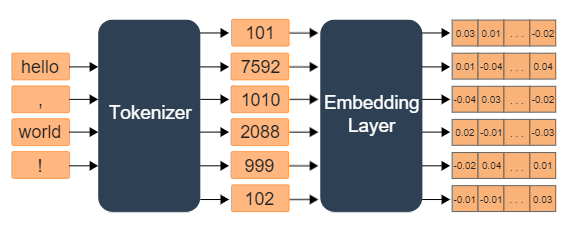

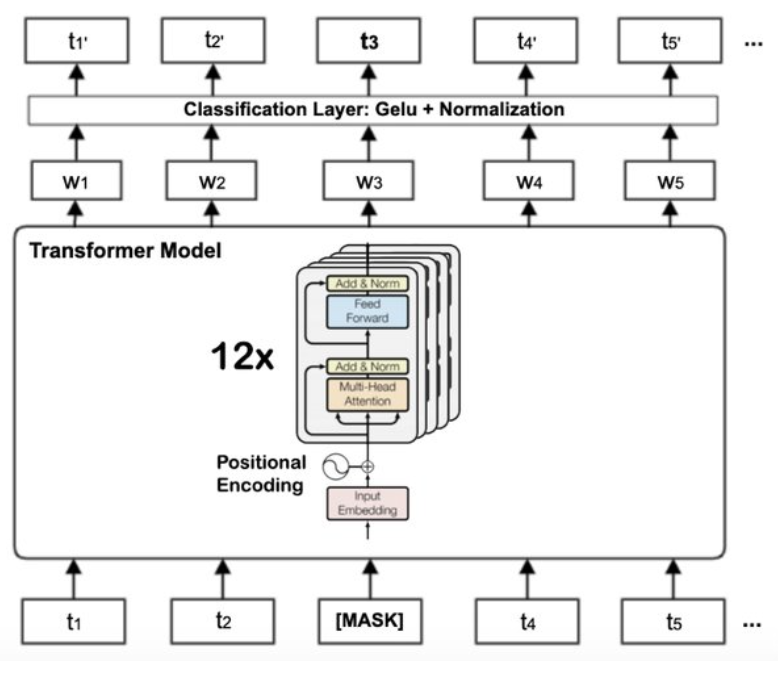

### Verifying Batch Shapes from the DataLoader

We draw a single batch from the DataLoader to confirm that the collation step stacks individual samples correctly. For a batch size of 8, we expect:

- `input_ids`: shape `[8, 512]`
- `attention_mask`: shape `[8, 512]`

Inspecting shapes at this stage catches dimension mismatches before they propagate into the model.

In [ ]:
sample_batch = next(iter(DataLoader(train_dataset, batch_size=8, num_workers=2)))
sample_batch["input_ids"].shape, sample_batch["attention_mask"].shape

### Sanity-Checking a Forward Pass Through BERT

We pass the sample batch through the pre-trained BERT model (before any fine-tuning) to verify that the pipeline is wired correctly and that no shape errors occur.

BERT returns two key outputs:

- **`last_hidden_state`** — shape `[batch, seq_len, 768]`: the contextual embedding for every token at every position in every sequence.
- **`pooler_output`** — shape `[batch, 768]`: a learned linear projection of the `[CLS]` token's hidden state, passed through a `tanh` activation. This is the vector we will use as input to our classification head.

In [ ]:
output = bert_model(sample_batch["input_ids"], sample_batch["attention_mask"])

In [ ]:
output.last_hidden_state.shape, output.pooler_output.shape

The hidden dimension of **768** is a core hyperparameter of `bert-base-cased` and determines the width of every layer in the transformer stack. It is stored in `bert_model.config.hidden_size`.

Our classification head is a single linear layer `nn.Linear(768, 6)` that projects this 768-dimensional `[CLS]` vector down to 6 logits — one per toxicity label.

In [ ]:
bert_model.config.hidden_size

### PyTorch Lightning DataModule

A `LightningDataModule` encapsulates all data-related logic: dataset instantiation, tokenization, and DataLoader creation for the train, validation, test, and prediction stages. This separation keeps the model code clean and makes the data pipeline fully reproducible and reusable.

In [ ]:
class ToxicCommentDataModule(pl.LightningDataModule):

  def __init__(self, train_df, val_df, test_df, tokenizer, batch_size=8, max_token_len=512):
    super().__init__()
    self.batch_size = batch_size
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df
    self.tokenizer = tokenizer
    self.max_token_len = max_token_len
    self.predict_texts = []

  def setup(self, stage=None):
    self.train_dataset = ToxicCommentsDataset(
      self.train_df,
      self.tokenizer,
      self.max_token_len
    )

    self.val_dataset = ToxicCommentsDataset(
      self.val_df,
      self.tokenizer,
      self.max_token_len
    )

    self.test_dataset = ToxicCommentsDataset(
      self.test_df,
      self.tokenizer,
      self.max_token_len
    )

  def train_dataloader(self):
    return DataLoader(
      self.train_dataset,
      batch_size=self.batch_size,
      shuffle=True,
      num_workers=2
    )

  def val_dataloader(self):
    return DataLoader(
      self.val_dataset,
      batch_size=self.batch_size,
      num_workers=2
    )

  def test_dataloader(self):
    return DataLoader(
      self.test_dataset,
      batch_size=self.batch_size,
      num_workers=2
    )

  def predict_dataloader(self):
    df = pd.DataFrame({
      'comment_text': self.predict_texts,
      **{col: [0] * len(self.predict_texts) for col in LABEL_COLUMNS}
    })
    dataset = ToxicCommentsDataset(df, self.tokenizer, self.max_token_len)
    return DataLoader(dataset, batch_size=self.batch_size, num_workers=2)


In [ ]:
N_EPOCHS = 50
BATCH_SIZE = 32
PATIENCE = 3

data_module = ToxicCommentDataModule(
  train_df,
  val_df,
  test_df,
  tokenizer,
  batch_size=BATCH_SIZE,
  max_token_len=MAX_TOKEN_COUNT
)

### PyTorch Lightning Model Module (`ToxicCommentTagger`)

The `LightningModule` wraps the BERT backbone and the classification head into a single trainable unit. It defines:

- **Architecture**: BERT encoder + `nn.Linear(768, 6)` head.
- **Loss function**: `BCEWithLogitsLoss` with per-class positive weights.
- **Optimizer and scheduler**: AdamW with linear warm-up and decay.
- **Step logic**: `training_step`, `validation_step`, and `test_step` methods that compute loss and log metrics.

We use `BCEWithLogitsLoss` rather than `CrossEntropyLoss` because this is a **multi-label** problem: each of the 6 labels is an independent binary classification, not a mutually exclusive category. `BCEWithLogitsLoss` applies a sigmoid internally to each logit and computes binary cross-entropy, which is numerically more stable than calling `sigmoid` followed by `BCELoss` separately.

In [ ]:
class ToxicCommentTagger(pl.LightningModule):

    def __init__(
        self,
        n_classes: int,
        n_training_steps=None,
        n_warmup_steps=None,
        pos_weight=None,
    ):
        super().__init__()
        self.bert = BertModel.from_pretrained(BERT_MODEL_NAME, return_dict=True)
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)
        self.n_classes = n_classes
        self.n_training_steps = n_training_steps
        self.n_warmup_steps = n_warmup_steps
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.accuracy = Accuracy(task="multilabel", num_labels=n_classes)
        self.auroc = AUROC(task="multilabel", num_labels=n_classes, average="macro")
        self.f1_macro = F1Score(
            task="multilabel", num_labels=n_classes, average="macro"
        )
        self.f1_micro = F1Score(
            task="multilabel", num_labels=n_classes, average="micro"
        )
        self.precision = Precision(
            task="multilabel", num_labels=n_classes, average="macro"
        )
        self.recall = Recall(task="multilabel", num_labels=n_classes, average="macro")
        self.avg_prec = AveragePrecision(
            task="multilabel", num_labels=n_classes, average="macro"
        )
        self.hamming = HammingDistance(task="multilabel", num_labels=n_classes)
        self.f1_per_class = F1Score(
            task="multilabel", num_labels=n_classes, average=None
        )

    def forward(self, input_ids, attention_mask, labels=None):
        output = self.bert(input_ids, attention_mask=attention_mask)
        logits = self.classifier(
            output.pooler_output
        )  # embedding token CLS after the encoder stack
        loss = 0

        # for train, val and test stages, labels exist
        # but not for predict stage
        if labels is not None:
            loss = self.criterion(logits, labels)
        predictions = torch.sigmoid(logits)
        return loss, predictions

    def training_step(self, batch, batch_idx):
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]
        loss, outputs = self(input_ids, attention_mask, labels)
        self.log("train_loss", loss, prog_bar=True, logger=True)
        return {"loss": loss, "predictions": outputs, "labels": labels}

    def validation_step(self, batch, batch_idx):
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]
        loss, outputs = self(input_ids, attention_mask, labels)
        self.log("val_loss", loss, prog_bar=True, logger=True)
        return loss

    def test_step(self, batch, batch_idx):
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]
        loss, outputs = self(input_ids, attention_mask, labels)
        self.log("test_loss", loss, prog_bar=True, logger=True)
        # Update metrics in-place: predictions and metrics are on the same device (GPU)
        targets = labels.int()
        self.accuracy.update(outputs, targets)
        self.auroc.update(outputs, targets)
        self.f1_macro.update(outputs, targets)
        self.f1_micro.update(outputs, targets)
        self.precision.update(outputs, targets)
        self.recall.update(outputs, targets)
        self.avg_prec.update(outputs, targets)
        self.hamming.update(outputs, targets)
        self.f1_per_class.update(outputs, targets)
        return loss

    def on_test_epoch_end(self):
        accuracy = self.accuracy.compute()
        auroc = self.auroc.compute()
        f1_macro = self.f1_macro.compute()
        f1_micro = self.f1_micro.compute()
        precision = self.precision.compute()
        recall = self.recall.compute()
        avg_prec = self.avg_prec.compute()
        hamming = self.hamming.compute()
        f1_per_cls = self.f1_per_class.compute()

        self.log_dict(
            {
                "test_accuracy": accuracy,
                "test_auroc": auroc,
                "test_f1_macro": f1_macro,
                "test_f1_micro": f1_micro,
                "test_precision_macro": precision,
                "test_recall_macro": recall,
                "test_map": avg_prec,
                "test_hamming": hamming,
            }
        )

        print(f"\n{'='*45}")
        print(f"{'Metric':<25} {'Value':>10}")
        print(f"{'='*45}")
        print(f"{'Accuracy (multilabel)':<25} {accuracy:>10.4f}")
        print(f"{'AUROC (macro)':<25} {auroc:>10.4f}")
        print(f"{'F1 (macro)':<25} {f1_macro:>10.4f}")
        print(f"{'F1 (micro)':<25} {f1_micro:>10.4f}")
        print(f"{'Precision (macro)':<25} {precision:>10.4f}")
        print(f"{'Recall (macro)':<25} {recall:>10.4f}")
        print(f"{'Avg Precision / mAP':<25} {avg_prec:>10.4f}")
        print(f"{'Hamming Distance':<25} {hamming:>10.4f}")
        print(f"{'='*45}")
        print(f"\nPer-class F1:")
        for label, score in zip(LABEL_COLUMNS, f1_per_cls):
            print(f"  {label:<20} {score:.4f}")

        # Reset all metrics for next use
        self.accuracy.reset()
        self.auroc.reset()
        self.f1_macro.reset()
        self.f1_micro.reset()
        self.precision.reset()
        self.recall.reset()
        self.avg_prec.reset()
        self.hamming.reset()
        self.f1_per_class.reset()

    def predict_step(self, batch, batch_idx):
        _, prediction = self(batch["input_ids"], batch["attention_mask"])
        return prediction

    def configure_optimizers(self):

        optimizer = AdamW(self.parameters(), lr=2e-5)

        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=self.n_warmup_steps,
            num_training_steps=self.n_training_steps,
        )

        return dict(
            optimizer=optimizer, lr_scheduler=dict(scheduler=scheduler, interval="step")
        )

### Learning Rate Scheduler Configuration

Fine-tuning a large pre-trained model like BERT is sensitive to the learning rate schedule. We use [`get_linear_schedule_with_warmup`](https://huggingface.co/transformers/main_classes/optimizer_schedules.html#transformers.get_linear_schedule_with_warmup) from HuggingFace Transformers.

The schedule has two phases:

1. **Warm-up phase**: The learning rate increases linearly from 0 to the target learning rate over the first `n_warmup_steps` steps.
2. **Decay phase**: The learning rate then decreases linearly from the target rate back to 0 over the remaining steps.

The toy example below simulates this schedule over 100 optimizer steps with a 20-step warm-up, so you can see the shape of the curve before applying it to the actual training run.

In [ ]:
dummy_model = nn.Linear(2, 1)

optimizer = AdamW(params=dummy_model.parameters(), lr=0.001)

warmup_steps = 20
total_training_steps = 100

scheduler = get_linear_schedule_with_warmup(
  optimizer,
  num_warmup_steps=warmup_steps,
  num_training_steps=total_training_steps
)

learning_rate_history = []

for step in range(total_training_steps):
  optimizer.step()
  scheduler.step()
  learning_rate_history.append(optimizer.param_groups[0]['lr'])

In [ ]:
plt.plot(learning_rate_history, label="learning rate")
plt.axvline(x=warmup_steps, color="red", linestyle=(0, (5, 10)), label="warmup end")
plt.legend()
plt.xlabel("Step")
plt.ylabel("Learning rate")
plt.tight_layout();

The plot makes the two-phase schedule visible:

- **Steps 0 → 20 (warm-up)**: The learning rate ramps up linearly. Starting from a near-zero learning rate prevents large gradient updates from immediately destabilizing the pre-trained weights, which encode years of language structure learned during pre-training.
- **Steps 20 → 100 (decay)**: The learning rate decreases linearly toward zero. This gradual reduction allows the optimizer to make increasingly fine-grained adjustments as it converges, avoiding overshooting a good minimum.

Without warm-up, the initial high learning rate combined with the random classifier head can produce large gradients that propagate back and corrupt BERT's pre-trained representations in the first few steps.

**Configuration exploration**: We compute and print `steps_per_epoch` and `total_training_steps` because these numbers are required inputs to the learning rate scheduler. Printing them makes the scheduler's warm-up budget concrete and auditable — you can immediately verify that `warmup_steps` is a sensible fraction of `total_training_steps`.

In [ ]:
steps_per_epoch=len(train_df) // BATCH_SIZE
print("Pasos por época: ", steps_per_epoch)
total_training_steps = steps_per_epoch * N_EPOCHS
print("Pasos totales de acuerdo a las épocas: ", total_training_steps)

We allocate **one-fifth of the total training steps** as the warm-up budget. This is a common rule of thumb for BERT fine-tuning and balances the benefit of gradual ramp-up against the cost of delaying full-rate training.

In [ ]:
warmup_steps = total_training_steps // 5
warmup_steps, total_training_steps

**Data exploration**: We print the per-class positive weight to make the class imbalance visible at the label level. A large weight for a given class (e.g., 14.0 for `identity_hate`) means positive examples are much rarer than negatives, and the loss will scale their gradients accordingly. Inspecting these values confirms that the weighting strategy is consistent with the observed label frequencies.

In [ ]:
pos_weight = (len(train_df) - train_df[LABEL_COLUMNS].sum()) / train_df[LABEL_COLUMNS].sum()
pos_weight = torch.FloatTensor(pos_weight.values.copy())
print("pos_weight per class:")
for label, w in zip(LABEL_COLUMNS, pos_weight):
    print(f"  {label:<20} {w:.2f}")

In [ ]:
model = ToxicCommentTagger(
  n_classes=len(LABEL_COLUMNS),
  n_warmup_steps=warmup_steps,
  n_training_steps=total_training_steps,
  pos_weight=pos_weight
)

### Multi-Label Classification as Independent Binary Classifiers

Unlike multi-class classification (where `softmax` forces probabilities to sum to 1 and exactly one class "wins"), multi-label classification treats each label as a **separate binary decision**. A comment can simultaneously be `toxic`, `obscene`, and `insult` — the labels are not mutually exclusive.

**Architecture implication**: The output layer produces 6 independent logits (one per label). A `sigmoid` is applied to each logit independently to produce a probability in `[0, 1]`. During inference, a threshold (default `0.5`) converts each probability to a binary prediction.

**Loss implication**: We use `nn.BCEWithLogitsLoss` (Binary Cross-Entropy with integrated sigmoid), not `CrossEntropyLoss`. The worked example below illustrates forward-pass logits → sigmoid probabilities → BCE loss for a 6-class prediction.

In [ ]:
criterion = nn.BCELoss()

prediction = torch.FloatTensor(
  [10.95873564, 1.07321467, 1.58524066, 0.03839076, 15.72987556, 1.09513213]
)
labels = torch.FloatTensor(
  [1., 0., 0., 0., 1., 0.]
)

In [ ]:
torch.sigmoid(prediction)

In [ ]:
criterion(torch.sigmoid(prediction), labels)

## Training

### Training Callbacks

PyTorch Lightning callbacks hook into the training loop at defined events without modifying model code. We configure four callbacks:

- **`ModelCheckpoint`**: Saves the model checkpoint with the lowest `val_loss` (`save_top_k=1`) and always saves the last epoch (`save_last=True`). The best checkpoint is later used for evaluation and prediction.
- **`EarlyStopping`**: Halts training if `val_loss` does not improve for `PATIENCE` consecutive epochs, preventing overfitting and wasting compute.
- **`SimpleEpochProgressCallback`** (custom): Prints a concise one-line summary per epoch (train loss, val loss, val accuracy, elapsed time) without the overhead of a full progress bar.
- **`CSVLogger`**: Logs all metrics to a CSV file for post-training analysis and plotting.

In [ ]:
logger = CSVLogger(save_dir=f"{LOGS_DIR}/logs-bert-GRUPOX/", name="week3-bert")

checkpoint_callback = ModelCheckpoint(
  save_top_k=1,
  save_last=True,
  verbose=True,
  monitor="val_loss",
  mode="min"
)

callback_tqdm = RichProgressBar(leave=True) #not used

early_stopping_callback = EarlyStopping(monitor='val_loss', patience=PATIENCE)

**Training observability**: The `SimpleEpochProgressCallback` replaces the default Lightning progress bar with a minimal one-line-per-epoch summary (train loss, validation loss, validation accuracy, elapsed time). The prints here are monitoring tools, not part of the model's forward pass or evaluation logic.

In [ ]:
import time

class SimpleEpochProgressCallback(pl.Callback):
    """Lightweight callback to show epoch progress without progress bar overhead."""

    def __init__(self):
        super().__init__()
        self.epoch_start_time = None

    def on_train_start(self, trainer, pl_module):
        """Print training configuration at the start."""
        train_dataloader = trainer.train_dataloader

        # Get batch size and number of batches
        if hasattr(train_dataloader, 'batch_size'):
            batch_size = train_dataloader.batch_size
        elif hasattr(train_dataloader, 'loaders') and hasattr(train_dataloader.loaders, 'batch_size'):
            batch_size = train_dataloader.loaders.batch_size
        else:
            batch_size = getattr(train_dataloader, 'batch_size', 'N/A')

        num_batches = len(train_dataloader)

        print(f"\nTraining Configuration: Batch Size={batch_size}, Steps per Epoch={num_batches}\n")

    def on_train_epoch_start(self, trainer, pl_module):
        """Record the start time of the epoch."""
        self.epoch_start_time = time.time()

    def on_train_epoch_end(self, trainer, pl_module):
        """Print single-line summary at the end of each training epoch."""
        current_epoch = trainer.current_epoch + 1
        max_epochs = trainer.max_epochs

        # Calculate epoch duration
        epoch_time = time.time() - self.epoch_start_time if self.epoch_start_time else 0

        # Get metrics from logged values
        train_loss = trainer.callback_metrics.get('train_loss', None)
        val_loss = trainer.callback_metrics.get('val_loss', None)
        val_acc = trainer.callback_metrics.get('val_acc', None)

        # Build single-line output
        parts = [f"Epoch {current_epoch}/{max_epochs}"]

        if train_loss is not None:
            parts.append(f"Train Loss: {train_loss:.4f}")
        if val_loss is not None:
            parts.append(f"Val Loss: {val_loss:.4f}")
        if val_acc is not None:
            parts.append(f"Val Acc: {val_acc:.4f}")

        parts.append(f"Time: {epoch_time:.2f}s")

        print(" | ".join(parts))

epoch_progress = SimpleEpochProgressCallback()


### Starting the Training Loop

With the model, data module, and callbacks configured, we hand everything to the Lightning `Trainer`. Lightning handles the training loop, gradient accumulation, metric logging, checkpointing, and device placement automatically.

Key `Trainer` arguments:
- `accelerator="auto"` / `devices="auto"`: Uses a GPU if available, falls back to CPU otherwise.
- `max_epochs=N_EPOCHS`: Upper bound on epochs; early stopping may terminate sooner.
- `log_every_n_steps=100`: Controls logging frequency to avoid I/O overhead.

In [ ]:
trainer = pl.Trainer(
  logger=logger,
  callbacks=[checkpoint_callback, early_stopping_callback, epoch_progress],
  max_epochs=N_EPOCHS,
  accelerator="auto",  # Uses GPUs or TPUs if available
  devices="auto",  # Uses all available GPUs/TPUs if applicable
  log_every_n_steps=100,
  enable_progress_bar=False
)

In [ ]:
torch.set_float32_matmul_precision('medium')
trainer.fit(model, data_module)

In [ ]:
# Evaluate on the test set using the best checkpoint — no manual loops needed
trainer.test(ckpt_path="best", datamodule=data_module)

In [ ]:
import glob

# Find latest CSV log produced by CSVLogger
log_files = sorted(glob.glob("logs-bert-GRUPOX/week3-bert/version_*/metrics.csv"))
metrics_df = pd.read_csv(log_files[-1])

# train_loss and val_loss are logged on different steps/rows; aggregate by epoch
train_loss = metrics_df.dropna(subset=["train_loss"]).groupby("epoch")["train_loss"].mean()
val_loss   = metrics_df.dropna(subset=["val_loss"]).groupby("epoch")["val_loss"].mean()

plt.figure(figsize=(10, 5))
plt.plot(train_loss.index, train_loss.values, label="Train Loss")
plt.plot(val_loss.index,   val_loss.values,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

## Predictions

We run inference using `trainer.predict()` with `ckpt_path="best"`, which automatically loads the checkpoint that achieved the lowest validation loss during training — not the weights from the final epoch. This is important because the final epoch's weights may be overfit relative to the best checkpoint.

`trainer.predict()` calls the `predict_step` method, which applies `torch.sigmoid` to the raw logits and returns probabilities in `[0, 1]` for each of the 6 toxicity labels.

We apply the trained model to a set of held-out test comments that were not seen during training or validation. A **probability threshold of 0.5** converts each sigmoid output to a binary prediction:

- Probability ≥ 0.5 → label predicted as **1** (toxic under that category).
- Probability < 0.5 → label predicted as **0** (not toxic under that category).

The threshold of 0.5 is a common default but can be tuned per class — a lower threshold increases recall (catches more toxic content) at the cost of more false positives, while a higher threshold increases precision.

In [ ]:
THRESHOLD = 0.3

test_comment = [
    "Thanks for sharing your idea, I think it's an interesting perspective.",
    "You are the worst person ever and nobody likes you.",
    "You are a completely worthless, disgusting excuse for a human being.",
    "This is complete bullshit and your stupid idea sucks.",
    "If you keep posting nonsense like this, I will report you and make sure you get banned from here.",
    "You're an idiot and clearly don't understand anything.",
    "People like you shouldn't exist in this community.",
    "I can’t stand g** people. They ruin everything."
]
data_module.predict_texts = test_comment
preds = trainer.predict(model, datamodule=data_module, ckpt_path="best")
all_preds = torch.cat(preds).numpy()
df = pd.DataFrame(all_preds, columns=LABEL_COLUMNS, index=test_comment)
df.style.highlight_between(left=THRESHOLD, right=1.0, color="lightcoral")